# ПРАКТИКА-02. Первичный анализ и предобработка данных.
---
- Работа с данными из LMS Moodle. Экспорт данных.
- Загрузка и первичный анализ данных.
- Предобработка данных



## Загрузим данные с курса LMS MOODLE
---

Если мы работаем со стандартным LMS MOODLE (из кооробки, без специального допиливания), то можно получить данные в нужном нам формате без привлечения программистов (без сложных запросов) из журнала оценок курса или из отчета результатов прохождения конкретного теста.

В этом уроке будем работать с данными из журнала оценок курса.

Для того, чтобы получить данные из журнала оценок выполним следующую последовательность действий:
- выбираем в палитре команд кнопку "Оценки";

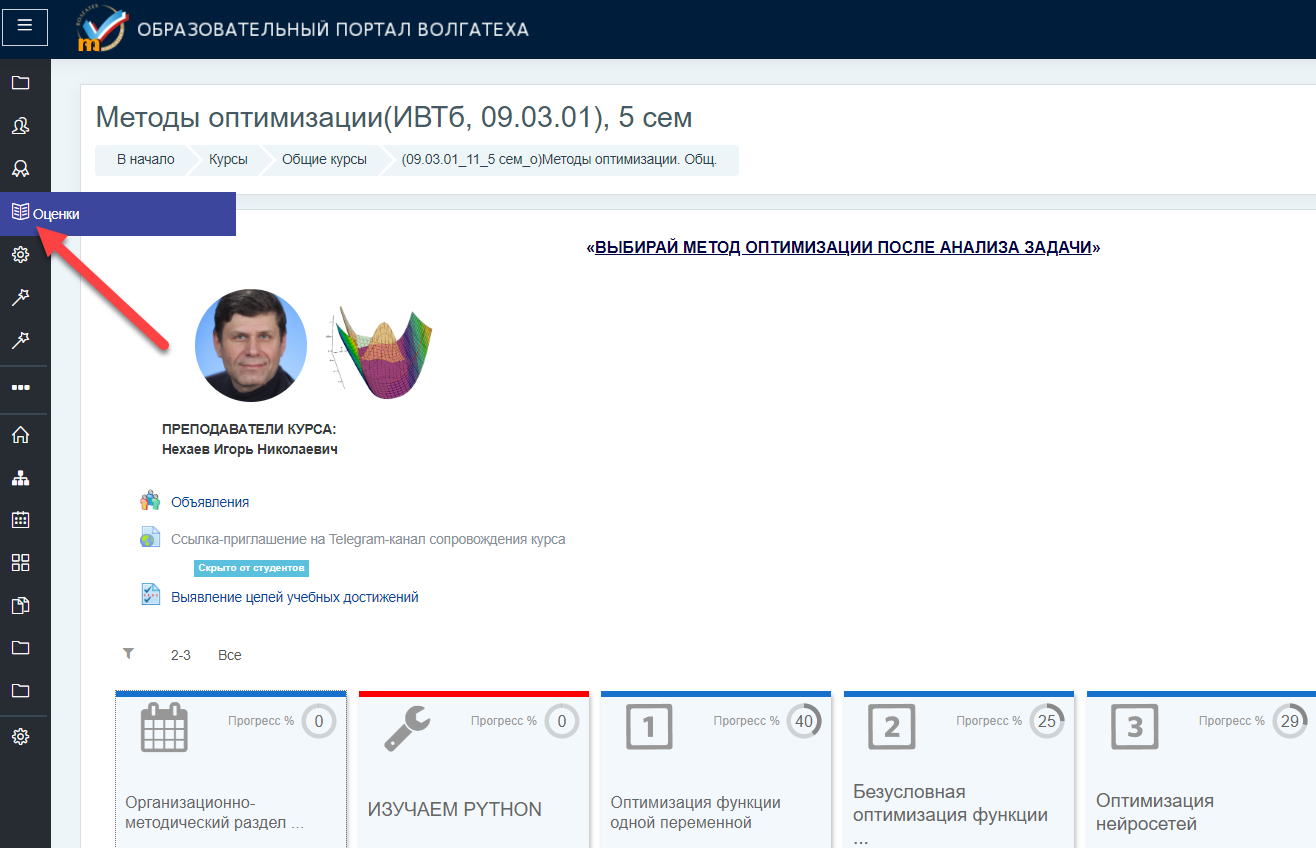

нажав на кнопку "Оценки" мы увидим журнал оценок в таком виде:

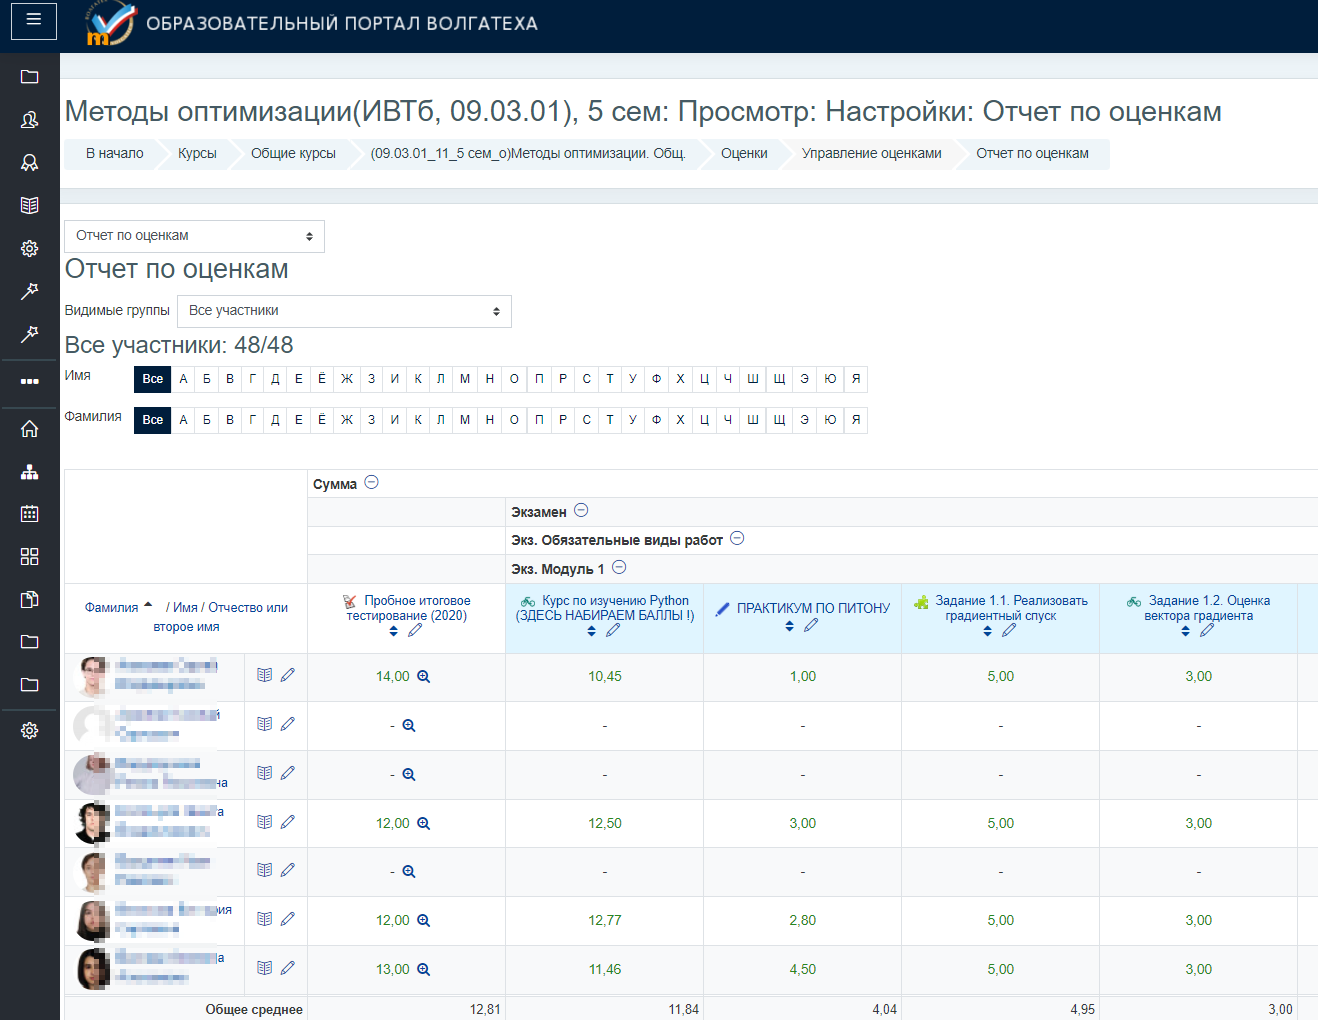

выбираем в поле "отчет по оценкам" пункт "Экспорт. Таблица Excel":


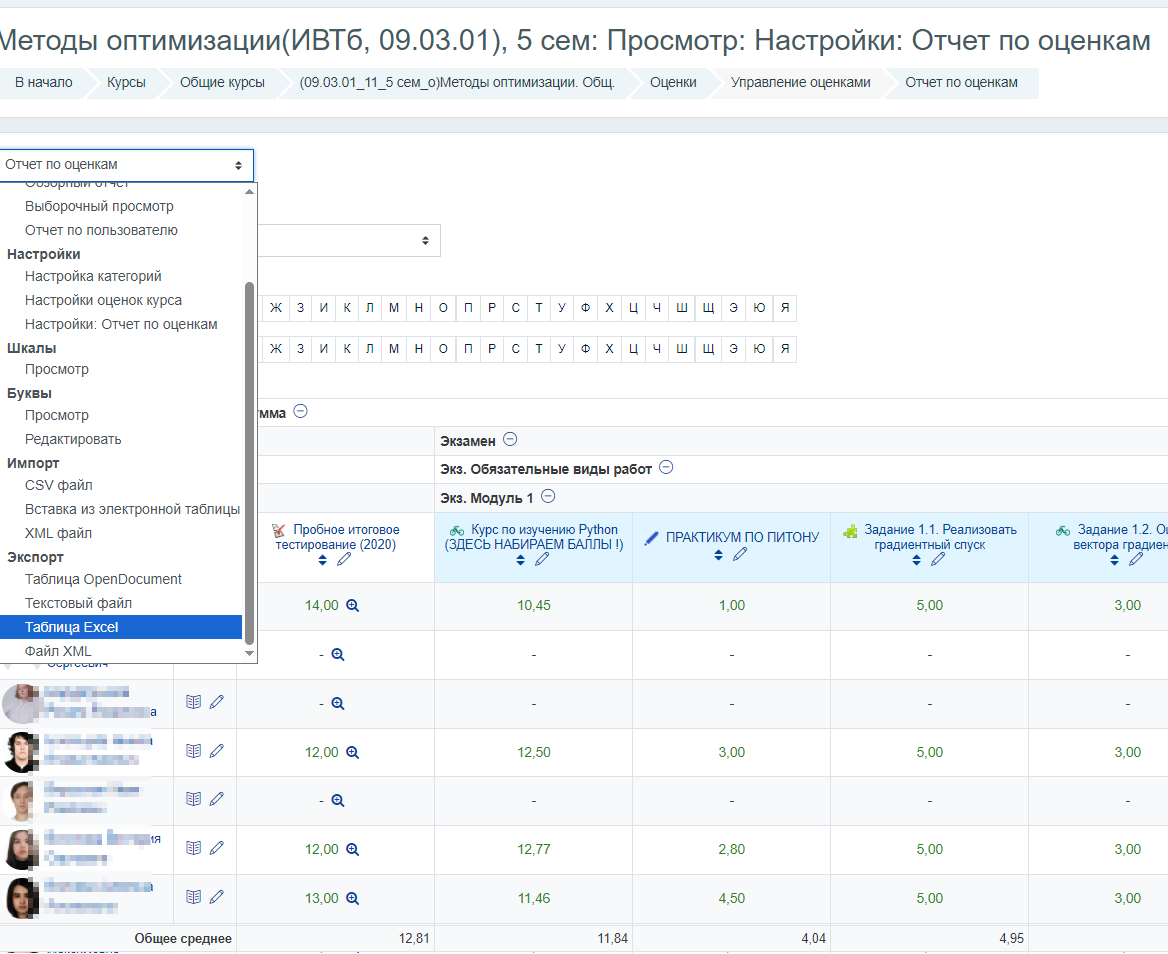

После этого нам предоставляется возможность выбрать какие из видов работ следует включить в экспортируемую таблицу баллов.

(не все работы, которые есть на курсе, являются актуальными для текущей версии курса)

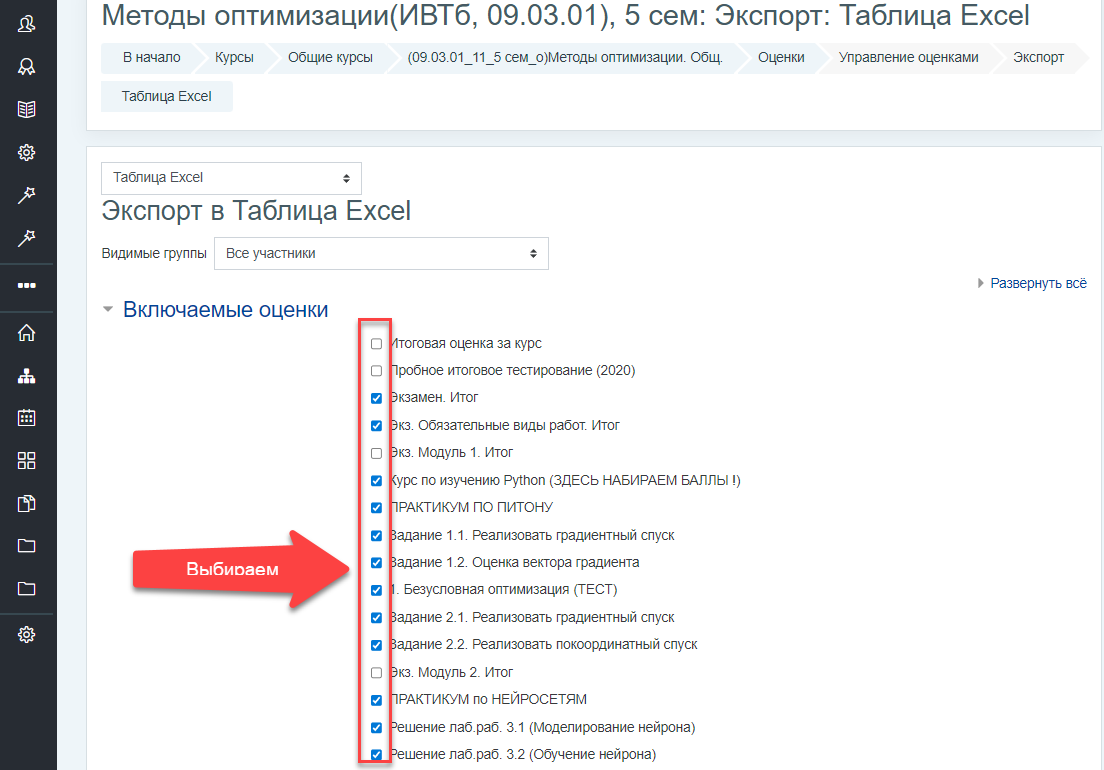

После завершения выбора останется только нажать кнопочку "Скачать" и файл загрузится на ваш компьютер

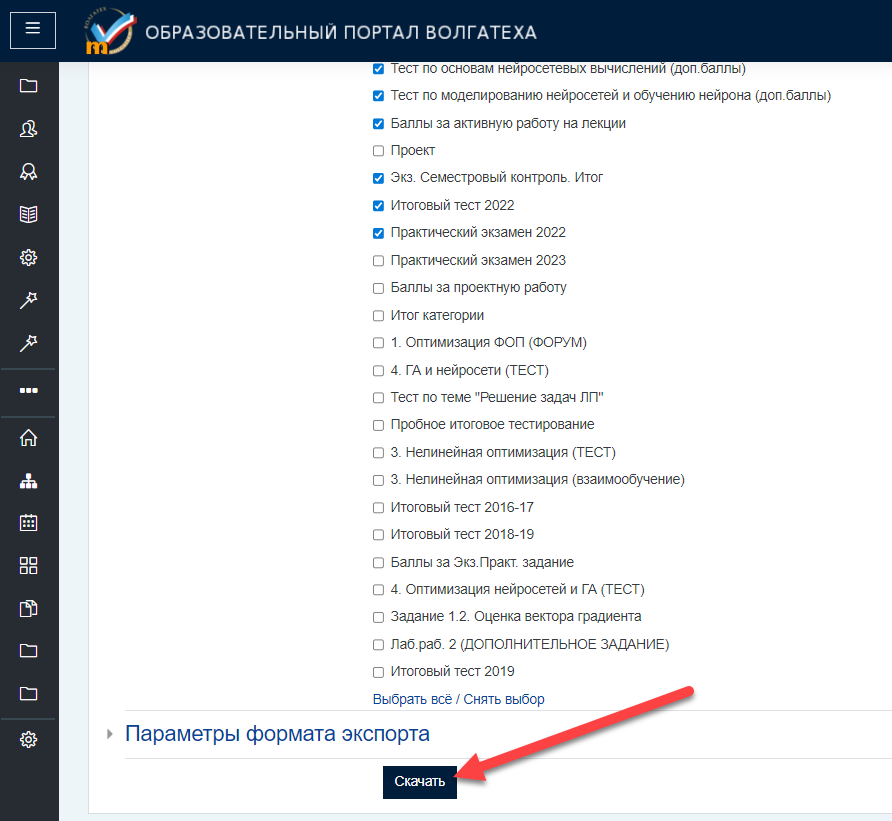

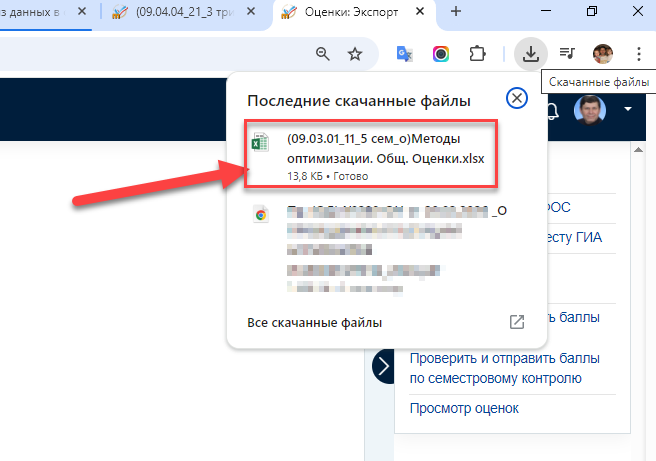

## Загрузка и первичный анализ данных.
---

Теперь мы можем загрузить данные из полученного файла. Для этого его надо поместить в папку виртуальной среды colab или на гугл-диск.

Данный файл ("Методы оптимизации. Оценки.xlsx") можно скачать с репозитория: https://github.com/garry-nn/Education_DA/tree/main/data


In [1]:
import pandas as pd
import numpy as np

filename = "Методы оптимизации. Оценки.xlsx"
df = pd.read_excel(filename)
df.tail()

,Фамилия,Имя,Индивидуальный номер,Экзамен. Итог (Значение),Экз. Обязательные виды работ. Итог (Значение),Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение),Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение),Внешний инструмент:Задание 1.1. Реализовать градиентный спуск (Значение),Внешний инструмент:Задание 1.2. Оценка вектора градиента (Значение),Тест:1. Безусловная оптимизация (ТЕСТ) (Значение),...,Внешний инструмент:Решение лаб.раб. 4.2 (классификация) (Значение),Экз. Дополнительные баллы. Итог (Значение),Задание:ПРАКТИКУМ ПО безусловной ОПТИМИЗАЦИИ (Значение),Внешний инструмент:Тест по основам нейросетевых вычислений (доп.баллы) (Значение),Внешний инструмент:Тест по моделированию нейросетей и обучению нейрона (доп.баллы) (Значение),Задание:Баллы за активную работу на лекции (Значение),Экз. Семестровый контроль. Итог (Значение),Тест:Итоговый тест 2022 (Значение),Внешний инструмент:Практический экзамен 2022 (Значение),Последние загруженные из этого курса
43,ФИО-44,Екатерина,1230400044,83.91,59.84,13.76,6,4,3,4.38,...,5,11.9,-,5,4,2.9,12.17,12.17,-,1774461271
44,ФИО-45,Валерия,1230400045,80.96,57.46,11.92,4,5,3,4.38,...,5,12.5,-,5,5,2.5,11,11,-,1774461271
45,ФИО-46,Лев,1230400046,79.96,51.96,11.43,4.5,5,3,4.38,...,-,16.5,3,5,5,3.5,11.5,7.5,4,1774461271
46,ФИО-47,Лилия,1230400047,76.75,54.05,12.05,3,5,3,5,...,5,10.7,-,5,5,0.7,12,12,-,1774461271
47,ФИО-48,Константин,1230400048,85.63,60.57,14.54,5,5,3,5,...,4,10.57,2,4,3.67,0.9,14.5,9.5,5,1774461271


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 27 columns):
 #   Column                                                                                         Non-Null Count  Dtype 
---  ------                                                                                         --------------  ----- 
 0   Фамилия                                                                                        48 non-null     object
 1   Имя                                                                                            48 non-null     object
 2   Индивидуальный номер                                                                           48 non-null     int64 
 3   Экзамен. Итог (Значение)                                                                       48 non-null     object
 4   Экз. Обязательные виды работ. Итог (Значение)                                                  48 non-null     object
 5   Внешний инструмент:Курс по изуч

## Предобработка данных

### Преобразование столбцов с баллами в числовые
---

Все столбцы с баллами в совем названии имеют слово "Значение". Воспользуемся этим и преобразуем данные столбцы в числовой формат

In [4]:
# перепишем все названия столбцов, в которых есть слово "Значение" в список

num_columns = [name for name in df.columns if 'Значение' in name]
num_columns

['Экзамен. Итог (Значение)',
 'Экз. Обязательные виды работ. Итог (Значение)',
 'Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение)',
 'Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение)',
 'Внешний инструмент:Задание 1.1. Реализовать градиентный спуск (Значение)',
 'Внешний инструмент:Задание 1.2. Оценка вектора градиента (Значение)',
 'Тест:1. Безусловная оптимизация (ТЕСТ) (Значение)',
 'Внешний инструмент:Задание 2.1. Реализовать градиентный спуск (Значение)',
 'Внешний инструмент:Задание 2.2. Реализовать покоординатный спуск (Значение)',
 'Задание:ПРАКТИКУМ по НЕЙРОСЕТЯМ (Значение)',
 'Внешний инструмент:Решение лаб.раб. 3.1 (Моделирование нейрона) (Значение)',
 'Внешний инструмент:Решение лаб.раб. 3.2 (Обучение нейрона) (Значение)',
 'Тест:4. Оптимизация нейросетей (ТЕСТ) (Значение)',
 'Внешний инструмент:Решение лаб.раб. 4.1 (автоэнкодинг) (Значение)',
 'Внешний инструмент:Решение лаб.раб. 4.2 (классификация) (Значение)',
 'Экз. Дополнительные баллы. Итог (Значен

In [3]:
# Данные каждого столбца из списка преобразуем в числовой формат, ошибки заменим как NaN
for col in num_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 27 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   Фамилия                                                                                        48 non-null     object 
 1   Имя                                                                                            48 non-null     object 
 2   Индивидуальный номер                                                                           48 non-null     int64  
 3   Экзамен. Итог (Значение)                                                                       45 non-null     float64
 4   Экз. Обязательные виды работ. Итог (Значение)                                                  44 non-null     float64
 5   Внешний инструмент:Курс 

In [6]:
# Посмотрим на несколько случайных строк из таблицы:
df.sample(7)

,Фамилия,Имя,Индивидуальный номер,Экзамен. Итог (Значение),Экз. Обязательные виды работ. Итог (Значение),Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение),Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение),Внешний инструмент:Задание 1.1. Реализовать градиентный спуск (Значение),Внешний инструмент:Задание 1.2. Оценка вектора градиента (Значение),Тест:1. Безусловная оптимизация (ТЕСТ) (Значение),...,Внешний инструмент:Решение лаб.раб. 4.2 (классификация) (Значение),Экз. Дополнительные баллы. Итог (Значение),Задание:ПРАКТИКУМ ПО безусловной ОПТИМИЗАЦИИ (Значение),Внешний инструмент:Тест по основам нейросетевых вычислений (доп.баллы) (Значение),Внешний инструмент:Тест по моделированию нейросетей и обучению нейрона (доп.баллы) (Значение),Задание:Баллы за активную работу на лекции (Значение),Экз. Семестровый контроль. Итог (Значение),Тест:Итоговый тест 2022 (Значение),Внешний инструмент:Практический экзамен 2022 (Значение),Последние загруженные из этого курса
18,ФИО-19,Павел,1230400019,79.00,52.60,11.77,5.0,5.0,3.0,3.75,...,4.0,12.40,0.1,4.0,5.00,3.3,14.0,9.0,5.0,1774461271
28,ФИО-29,Алексей,1230400029,73.95,49.65,5.38,2.0,5.0,3.0,5.00,...,4.0,11.30,1.0,5.0,5.00,0.3,13.0,13.0,NaN,1774461271
19,ФИО-20,Артем,1230400020,62.53,44.67,15.22,2.5,5.0,3.0,3.75,...,NaN,7.87,0.5,3.0,3.17,1.2,10.0,10.0,NaN,1774461271
32,ФИО-33,Александр,1230400033,95.29,63.29,11.69,5.5,5.0,3.0,4.38,...,5.0,20.00,4.9,5.0,5.00,5.1,12.0,12.0,NaN,1774461271
17,ФИО-18,Артем,1230400018,87.97,59.87,12.07,6.0,5.0,3.0,4.38,...,5.0,15.10,3.0,4.5,5.00,2.6,13.0,13.0,NaN,1774461271
29,ФИО-30,Владислав,1230400030,91.33,63.97,11.80,6.0,5.0,3.0,5.00,...,5.0,15.87,3.0,5.0,4.67,3.2,11.5,11.5,NaN,1774461271
13,ФИО-14,Вадим,1230400014,81.60,62.80,18.52,5.0,5.0,3.0,5.00,...,3.0,7.80,2.0,4.5,NaN,1.3,11.0,11.0,NaN,1774461271


### Фильтрация столбцов
---
Перед анализом данных отфильтруем лишние (неинформативные) столбцы:
- "Фамилия", "Имя" (их заменит "Индивидуальный номер");
- "Внешний инструмент:Практический экзамен 2022 (Значение)" - неинформативный из за того, что там сплошные пропуски значений (мало кто сдавал практическое экзаменационное задание);
- "Последние загруженные из этого курса" - эта информация ни о чем нам не говорит.

In [7]:
# точные названия столбцов можно взять отсюда

df.columns

Index(['Фамилия', 'Имя', 'Индивидуальный номер', 'Экзамен. Итог (Значение)',
       'Экз. Обязательные виды работ. Итог (Значение)',
       'Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение)',
       'Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение)',
       'Внешний инструмент:Задание 1.1. Реализовать градиентный спуск (Значение)',
       'Внешний инструмент:Задание 1.2. Оценка вектора градиента (Значение)',
       'Тест:1. Безусловная оптимизация (ТЕСТ) (Значение)',
       'Внешний инструмент:Задание 2.1. Реализовать градиентный спуск (Значение)',
       'Внешний инструмент:Задание 2.2. Реализовать покоординатный спуск (Значение)',
       'Задание:ПРАКТИКУМ по НЕЙРОСЕТЯМ (Значение)',
       'Внешний инструмент:Решение лаб.раб. 3.1 (Моделирование нейрона) (Значение)',
       'Внешний инструмент:Решение лаб.раб. 3.2 (Обучение нейрона) (Значение)',
       'Тест:4. Оптимизация нейросетей (ТЕСТ) (Значение)',
       'Внешний инструмент:Решение лаб.раб. 4.1 (автоэнкодинг)

In [8]:
# создадим новую таблицу, в которой не будет отфильтрованных столбцов

df_filtered = df.drop(columns=["Фамилия", "Имя", "Внешний инструмент:Практический экзамен 2022 (Значение)", "Последние загруженные из этого курса"])
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 23 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   Индивидуальный номер                                                                           48 non-null     int64  
 1   Экзамен. Итог (Значение)                                                                       45 non-null     float64
 2   Экз. Обязательные виды работ. Итог (Значение)                                                  44 non-null     float64
 3   Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение)                 43 non-null     float64
 4   Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение)                                                         40 non-null     float64
 5   Внешний инструмент:Задан

Мы оставили только нужные нам числовые столбцы. Теперь хорошо бы убрать бесполезные строки (учащихся, которые не набрали ни одного балла, т.е. не приступили к обучению на курсе).

Это можно понять по столбцу "Экз. Обязательные виды работ. Итог (Значение)".

Видим, что из 48 обучающихся только 44 имеют какой-то балл за обязательные виды работ. Отфильтруем неприступивших учащихся


### Фильтрация пустых строк

In [10]:
df_filtered = df_filtered.dropna(subset=['Экз. Обязательные виды работ. Итог (Значение)'], axis = 0)
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 47
Data columns (total 23 columns):
 #   Column                                                                                         Non-Null Count  Dtype  
---  ------                                                                                         --------------  -----  
 0   Индивидуальный номер                                                                           44 non-null     int64  
 1   Экзамен. Итог (Значение)                                                                       44 non-null     float64
 2   Экз. Обязательные виды работ. Итог (Значение)                                                  44 non-null     float64
 3   Внешний инструмент:Курс по изучению Python (ЗДЕСЬ НАБИРАЕМ БАЛЛЫ !) (Значение)                 43 non-null     float64
 4   Задание:ПРАКТИКУМ ПО ПИТОНУ (Значение)                                                         40 non-null     float64
 5   Внешний инструмент:Задание 1.

Мы оставили только нужные нам числовые столбцы и строки и теперь можем приступить к дальнейшему (разведочному) анализу данных.

На будущее, чтобы не выполнять эти операции снова, сохраним полученную таблицу.

### Сохраним таблицу на диск
---

In [11]:
newfilename = "Методы оптимизации - подготовленный.xlsx"
df_filtered.to_excel(newfilename)

In [12]:
# лучше на гугл-диск, чтобы сохраниля после завершения работы с блокнотом

path = "/content/drive/My Drive/Colab Notebooks/"
df_filtered.to_excel(path + newfilename)

## ЗАДАНИЕ (самостоятельная работа)
---

1. Скачайте файл ("LinAlg-2.xlsx") из репозитория: https://github.com/garry-nn/Education_DA/tree/main/data.
Выведите информацию о таблице (сколько строк, какие столбцы в таблице, формат каждого столбца).

2. Отфильтруйте нечисловые неинформативные для анализа столбцы (Имя, отчество, учреждение).

3. Выполните преобразование столбцов с баллами в числовой формат.

Выведите информацию о таблице, убедителсь в том, что столбцы с баллами имеют числовой формат.

4. Отфильтруйте пустые строки таблицы, в которых нет баллов.

Выведите на экран информацию о таблице.

5. Сохраните полученный файл на диск.

5. Напишите вывод:
- сколько учащихся было зарегистрировано на курсе (строк в таблице было после загрузки);
- какой % учащихся приступил к обучению (заработал любые баллы);
- сколько оцениваемых заданий было на курсе.

